In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:
df=pd.read_csv("/content/movies_metadata.csv")


In [5]:
df.loc[0]

,0
adult,False
belongs_to_collection,"{'id': 10194, 'name': 'Toy Story Collection', ..."
budget,30000000
genres,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
homepage,http://toystory.disney.com/toy-story
id,862
imdb_id,tt0114709
original_language,en
original_title,Toy Story
overview,"Led by Woody, Andy's toys live happily in his ..."


In [6]:
df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [7]:
df.shape

(29521, 24)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29521 entries, 0 to 29520
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  29521 non-null  object 
 1   belongs_to_collection  3314 non-null   object 
 2   budget                 29521 non-null  object 
 3   genres                 29521 non-null  object 
 4   homepage               4782 non-null   object 
 5   id                     29521 non-null  object 
 6   imdb_id                29509 non-null  object 
 7   original_language      29518 non-null  object 
 8   original_title         29521 non-null  object 
 9   overview               29197 non-null  object 
 10  popularity             29516 non-null  float64
 11  poster_path            29358 non-null  object 
 12  production_companies   29518 non-null  object 
 13  production_countries   29518 non-null  object 
 14  release_date           29489 non-null  object 
 15  re

In [9]:
df.duplicated().sum()

np.int64(12)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isna().sum()

,0
adult,0
belongs_to_collection,26195
budget,0
genres,0
homepage,24729
id,0
imdb_id,12
original_language,3
original_title,0
overview,324


In [13]:
df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [14]:
df=df[["title","overview","genres","tagline","vote_average","popularity"]]

In [15]:
df.head(1)

,title,overview,genres,tagline,vote_average,popularity
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",NaN,7.7,21.946943


In [16]:
df.loc[0]["genres"]

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

In [17]:
df.isnull().sum()

,0
title,5
overview,324
genres,0
tagline,13805
vote_average,5
popularity,5


In [18]:
df=df.dropna(subset=["title"])

In [19]:
df["overview"]=df["overview"].fillna("")

In [20]:
df.loc[0]["genres"]

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

In [21]:
df["genres"]=df["genres"].apply(lambda x :[ i["name"] for i in eval(x) ])

In [22]:
df["genres"]=df["genres"].apply(lambda x :  " ".join(x))

In [23]:
df["tagline"]=df['tagline'].fillna(" ")

In [24]:
df.isna().sum()

,0
title,0
overview,0
genres,0
tagline,0
vote_average,0
popularity,0


In [25]:
df["tags"]=df['overview']+" "+df["genres"]+" "+df["tagline"]

In [26]:
df.loc[1]["tags"]

"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures. Adventure Fantasy Family Roll the dice and unleash the excitement!"

In [27]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [28]:
stwords=stopwords.words("english")

In [29]:
len(stwords)

198

In [30]:
lemmatizer=WordNetLemmatizer()

In [31]:
def preprocess(text):
  text=text.lower()
  pretext=re.sub(r'[^\w\s]','',text)
  tokens=word_tokenize(pretext)
  tokens = [word for word in tokens if word not in stwords]
  tokens=[lemmatizer.lemmatize(word) for word in tokens]
  return " ".join(tokens)

In [32]:
df["tags"]=df["tags"].apply(preprocess)

In [33]:
df["tags"][1]

'sibling judy peter discover enchanted board game open door magical world unwittingly invite alan adult who trapped inside game 26 year living room alans hope freedom finish game prof risky three find running giant rhinoceros evil monkey terrifying creature adventure fantasy family roll dice unleash excitement'

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [35]:
df=df.reset_index(drop=True)

In [36]:
indices=pd.Series(df.index,index=df["title"]).drop_duplicates()

In [37]:
vec=TfidfVectorizer(max_features=50000,stop_words="english",ngram_range=(1,2))

In [38]:
newtags=vec.fit_transform(df["tags"])

In [62]:
newtags

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1045593 stored elements and shape (29504, 50000)>

In [45]:
len(vec.vocabulary_)

50000

In [39]:
newtags.shape

(29504, 50000)

In [40]:
from sklearn.cluster import KMeans

In [41]:
model=KMeans(n_clusters=10,random_state=42)

In [46]:
lis=[]
# for i in range(10,20):
#   model=KMeans(n_clusters=i,random_state=42,n_init=10)
#   model.fit(newtags)
#   lis.append(model.inertia_)

In [47]:
lis

[28792.05789887478,
 28772.103385082224,
 28752.811543134678,
 28732.71653313964,
 28709.983182006166,
 28699.24881377848,
 28682.005940154748,
 28656.678864089277,
 28641.242797573108,
 28627.17753693686]

In [ ]:
#you get these values once you run . its take slong time to run so can use this
# lis=[28792.05789887478,
#  28772.103385082224,
#  28752.811543134678,
#  28732.71653313964,
#  28709.983182006166,
#  28699.24881377848,
#  28682.005940154748,
#  28656.678864089277,
#  28641.242797573108,
#  28627.17753693686]

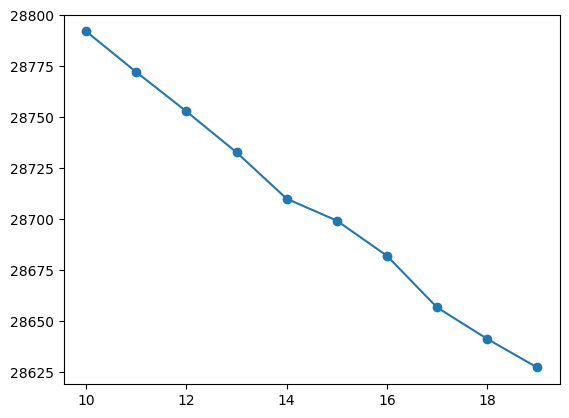

In [49]:
plt.plot(range(10,20),lis,marker="o")

In [50]:
from sklearn.metrics.pairwise import cosine_similarity

In [63]:
from scipy.stats.distributions import cosine
def recommend(title,n=10):
  if title not in indices:
    return ["Movie not found"]
  idx=indices[title]
  sim_score=cosine_similarity(newtags[idx],newtags).flatten()
  similar_idx=sim_score.argsort()[::-1][1:n+1]
  return df["title"].iloc[similar_idx]

In [75]:
search=input("Enter movie name: ").title()
print(recommend(search))

Enter movie name: avenger
5054                          Hopscotch
871              The Philadelphia Story
4367                             D.O.A.
12061                 The Hunting Party
7842     Now You See Him, Now You Don't
584                    Tough and Deadly
25089                  Hit by Lightning
7871                       The Escapist
5279                        Bad Company
13976     Silent Night, Deadly Night II
Name: title, dtype: object


In [70]:
import pickle

In [73]:
pickle.dump(newtags,open("newtags.pkl","wb"))
pickle.dump(df,open("df.pkl","wb"))
pickle.dump(indices,open("indices.pkl","wb"))
pickle.dump(vec,open("vec.pkl","wb"))